# Results: Detecting Depression — Word-Embeddings and Sentence Transformers

Loads the recorded results (`results/final_results.csv` and
`results/cross_domain_rf_results.csv`) and recreates the comparison figures of
the paper: GLoVe aggregation methods, classifier comparisons against the TF-IDF
baseline, the sentence transformers, and the keyword-removal study.

In [1]:
import os
# run from the repository root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv('results/final_results.csv')
results['F1'] = results['F1-Score'].str.rstrip('%').astype(float)
results['Acc'] = results['Accuracy'].str.rstrip('%').astype(float)

TFIDF_BASELINE_F1 = 93.24   # the TF-IDF baseline of the preceding conference paper

results[['Filename', 'Model', 'F1-Score', 'Accuracy', 'F1-Variance', 'Accuracy-Variance']]

,Filename,Model,F1-Score,Accuracy,F1-Variance,Accuracy-Variance
0,transformer/transformer_all_minilm_l6_v2.csv,Random Forest,96.96%,97.00%,0.000089,0.000087
1,transformer/transformer_all_minilm_l6_v2.csv,Logistic Regression,96.73%,96.71%,0.000020,0.000022
2,transformer/transformer_all_minilm_l6_v2.csv,Neural Network,96.78%,96.79%,0.000042,0.000045
3,transformer/transformer_all_mpnet_base_v2.csv,Random Forest,98.04%,98.07%,0.000044,0.000042
4,transformer/transformer_all_mpnet_base_v2.csv,Logistic Regression,97.22%,97.21%,0.000009,0.000009
5,transformer/transformer_all_mpnet_base_v2.csv,Neural Network,97.15%,97.14%,0.000006,0.000006
6,transformer/transformer_gtr_t5_base.csv,Random Forest,96.34%,96.43%,0.000159,0.000147
7,transformer/transformer_gtr_t5_base.csv,Logistic Regression,97.79%,97.79%,0.000041,0.000041
8,transformer/transformer_gtr_t5_base.csv,Neural Network,97.37%,97.36%,0.000029,0.000029
9,transformer/transformer_sentence_t5_base.csv,Random Forest,97.33%,97.36%,0.000018,0.000017


In [2]:
# Readable feature-set names
def feature_name(filename):
    base = os.path.basename(filename).replace('.csv', '')
    if base.startswith('word_embeddings'):
        _, _, dims, method = base.split('_')
        return f"{dims}-D ({method})"
    return {
        'transformer_all_minilm_l6_v2': 'All MiniLM L6 v2',
        'transformer_all_mpnet_base_v2': 'All MPNet base v2',
        'transformer_gtr_t5_base': 'GTR T5 base',
        'transformer_sentence_t5_base': 'Sentence T5 base',
    }[base]

results['Features'] = results['Filename'].apply(feature_name)

# F1 score (%) of every feature set x classifier combination
results.pivot(index='Features', columns='Model', values='F1').round(2)

Model,Logistic Regression,Neural Network,Random Forest
Features,,,
100-D (average),91.67,94.57,94.71
100-D (sum),91.72,93.18,92.95
200-D (average),92.61,94.91,94.61
200-D (sum),92.73,89.03,94.26
25-D (average),87.13,91.24,90.95
25-D (sum),89.40,90.02,91.60
50-D (average),89.51,93.21,94.34
50-D (sum),90.07,92.90,93.94
All MPNet base v2,97.22,97.15,98.04


## GLoVe: sum vs mean aggregation

Mean classification F1 over the three classifiers, for each of the eight
GLoVe feature sets. Averaging the word-vectors of a post (mean) outperforms
summing them, and higher-dimension embeddings tend to perform better.

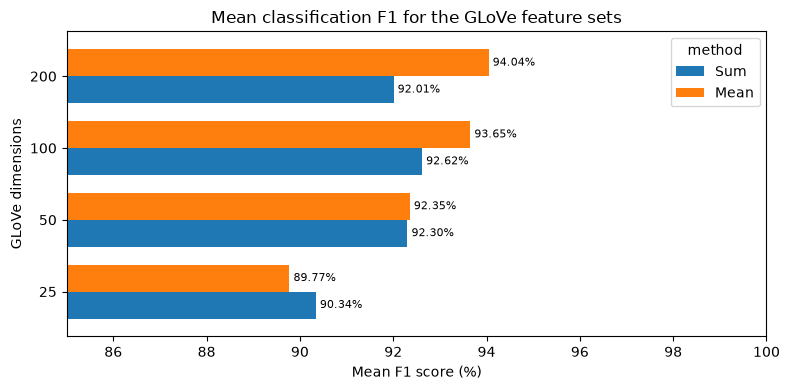

In [3]:
glove = results[results['Filename'].str.startswith('word_embeddings')].copy()
glove['dims'] = glove['Features'].str.split('-').str[0].astype(int)
glove['method'] = glove['Features'].str.extract(r'\((\w+)\)')

mean_f1 = glove.groupby(['dims', 'method'])['F1'].mean().unstack()
mean_f1 = mean_f1.rename(columns={'average': 'Mean', 'sum': 'Sum'})[['Sum', 'Mean']]

ax = mean_f1.plot(kind='barh', figsize=(8, 4), xlim=(85, 100), width=0.75)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=8)
ax.set_xlabel('Mean F1 score (%)')
ax.set_ylabel('GLoVe dimensions')
ax.set_title('Mean classification F1 for the GLoVe feature sets')
plt.tight_layout()
plt.show()

## Classifiers on mean-GLoVe features vs the TF-IDF baseline

Multiple GLoVe-based Random Forest and Multi-Layer Perceptron models beat the
TF-IDF baseline of the preceding paper (dashed line); Logistic Regression does
not.

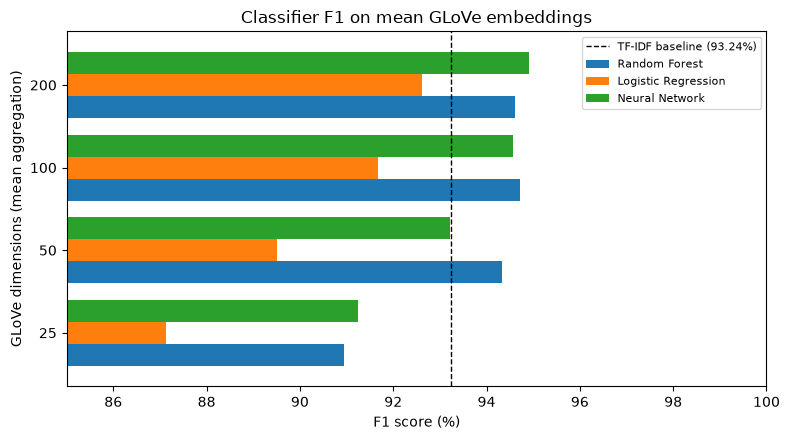

In [4]:
mean_glove = glove[glove['method'] == 'average']
pivot = mean_glove.pivot(index='dims', columns='Model', values='F1')
pivot = pivot[['Random Forest', 'Logistic Regression', 'Neural Network']]

ax = pivot.plot(kind='barh', figsize=(8, 4.5), xlim=(85, 100), width=0.8)
ax.axvline(TFIDF_BASELINE_F1, color='black', linestyle='--', linewidth=1,
           label=f'TF-IDF baseline ({TFIDF_BASELINE_F1}%)')
ax.set_xlabel('F1 score (%)')
ax.set_ylabel('GLoVe dimensions (mean aggregation)')
ax.set_title('Classifier F1 on mean GLoVe embeddings')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Sentence transformers vs the best baselines

Every sentence transformer surpasses both the TF-IDF baseline and the best
GLoVe feature set. The best overall model of the study is **All MPNet base v2 +
Random Forest**.

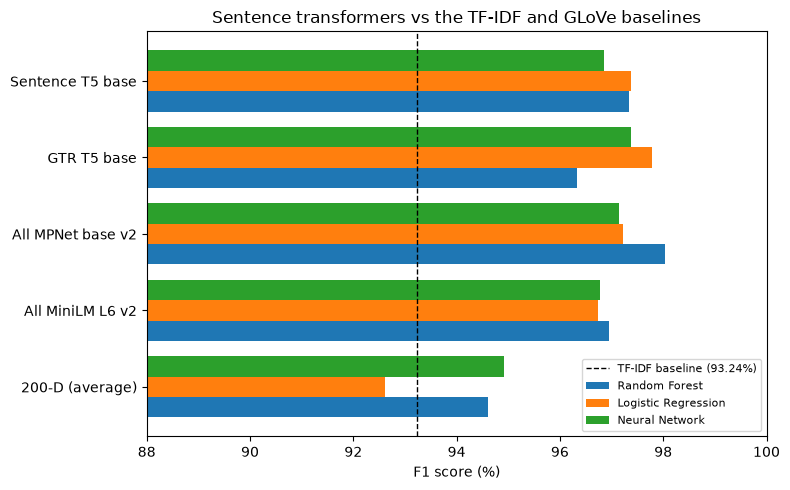

Best model: Random Forest on All MPNet base v2 - F1 98.04%, accuracy 98.07%


In [5]:
order = ['200-D (average)', 'All MiniLM L6 v2', 'All MPNet base v2', 'GTR T5 base', 'Sentence T5 base']
subset = results[results['Features'].isin(order)]
pivot = subset.pivot(index='Features', columns='Model', values='F1').reindex(order)
pivot = pivot[['Random Forest', 'Logistic Regression', 'Neural Network']]

ax = pivot.plot(kind='barh', figsize=(8, 5), xlim=(88, 100), width=0.8)
ax.axvline(TFIDF_BASELINE_F1, color='black', linestyle='--', linewidth=1,
           label=f'TF-IDF baseline ({TFIDF_BASELINE_F1}%)')
ax.set_xlabel('F1 score (%)')
ax.set_ylabel('')
ax.set_title('Sentence transformers vs the TF-IDF and GLoVe baselines')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

best = results.loc[results['F1'].idxmax()]
print(f"Best model: {best['Model']} on {best['Features']} - "
      f"F1 {best['F1-Score']}, accuracy {best['Accuracy']}")

## Effect of keyword removal (cleaning)

The controlled comparison trains simple Random Forests on cleaned vs original
(unclean) data in all four combinations (5-fold cross validation). Training on
cleaned data transfers *better* to unclean data than the reverse: removing the
clinical keywords produces more robust models.

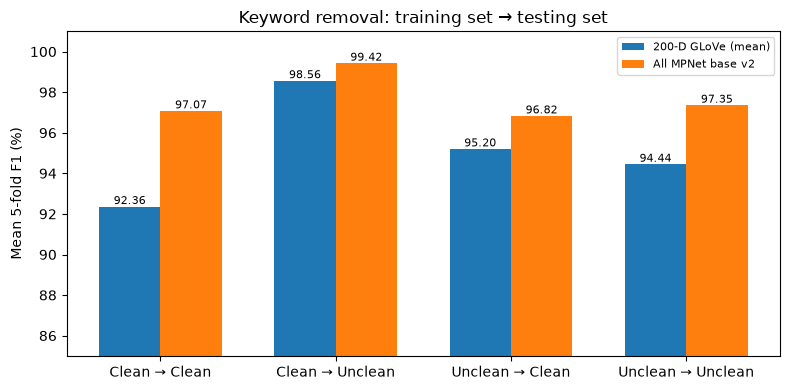

,file,train_clean_test_unclean_f1_mean,train_clean_test_unclean_f1_var,train_clean_test_unclean_acc_mean,train_clean_test_unclean_acc_var,train_unclean_test_clean_f1_mean,train_unclean_test_clean_f1_var,train_unclean_test_clean_acc_mean,train_unclean_test_clean_acc_var,train_clean_test_clean_f1_mean,train_clean_test_clean_f1_var,train_clean_test_clean_acc_mean,train_clean_test_clean_acc_var,train_unclean_test_unclean_f1_mean,train_unclean_test_unclean_f1_var,train_unclean_test_unclean_acc_mean,train_unclean_test_unclean_acc_var
0,transformer_all_minilm_l6_v2.csv,0.992089,0.000041,0.992125,0.000041,0.962105,0.000215,0.963466,0.000189,0.955783,0.000387,0.957025,0.000353,0.966235,0.000056,0.967043,0.000054
1,transformer_all_mpnet_base_v2.csv,0.994234,0.000030,0.994273,0.000029,0.968220,0.000063,0.969206,0.000054,0.970717,0.000054,0.971352,0.000051,0.973511,0.000075,0.974222,0.000066
2,transformer_gtr_t5_base.csv,0.993528,0.000016,0.993554,0.000015,0.957545,0.000124,0.959181,0.000105,0.950920,0.000390,0.952727,0.000349,0.963934,0.000065,0.964905,0.000060
3,transformer_sentence_t5_base.csv,0.992795,0.000033,0.992839,0.000032,0.975818,0.000072,0.976362,0.000068,0.965576,0.000254,0.966334,0.000241,0.973042,0.000057,0.973490,0.000056
4,word_embeddings_100_average.csv,0.985706,0.000031,0.985676,0.000032,0.949869,0.000063,0.952012,0.000048,0.932158,0.000071,0.933387,0.000067,0.949778,0.000067,0.950576,0.000060
5,word_embeddings_200_average.csv,0.985579,0.000087,0.985684,0.000083,0.951972,0.000256,0.954160,0.000214,0.923553,0.000109,0.925512,0.000084,0.944401,0.000074,0.945561,0.000067
6,word_embeddings_25_average.csv,0.903026,0.000356,0.902578,0.000362,0.862652,0.000753,0.870346,0.000638,0.892021,0.000389,0.892545,0.000406,0.918594,0.000197,0.919055,0.000209
7,word_embeddings_50_average.csv,0.974794,0.000059,0.974933,0.000057,0.953295,0.000060,0.954875,0.000048,0.917525,0.000531,0.918349,0.000501,0.941378,0.000094,0.941979,0.000086


In [6]:
cross = pd.read_csv('results/cross_domain_rf_results.csv')

files = {'word_embeddings_200_average.csv': '200-D GLoVe (mean)',
         'transformer_all_mpnet_base_v2.csv': 'All MPNet base v2'}
experiments = [('train_clean_test_clean', 'Clean \u2192 Clean'),
               ('train_clean_test_unclean', 'Clean \u2192 Unclean'),
               ('train_unclean_test_clean', 'Unclean \u2192 Clean'),
               ('train_unclean_test_unclean', 'Unclean \u2192 Unclean')]

x = np.arange(len(experiments))
fig, ax = plt.subplots(figsize=(8, 4))
for i, (file, label) in enumerate(files.items()):
    values = [cross.loc[cross['file'] == file, f'{e}_f1_mean'].iloc[0] * 100
              for e, _ in experiments]
    bars = ax.bar(x + i * 0.35, values, 0.35, label=label)
    ax.bar_label(bars, fmt='%.2f', fontsize=8)
ax.set_xticks(x + 0.175)
ax.set_xticklabels([name for _, name in experiments])
ax.set_ylim(85, 101)
ax.set_ylabel('Mean 5-fold F1 (%)')
ax.set_title('Keyword removal: training set \u2192 testing set')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

cross